## 0. Notebook Overview

* **Goal:** Build an end-to-end image segmentation workflow using Meta's SAM (Segment Anything Model) via HuggingFace Transformers.

**Workflow:**
1. Install dependencies and import libraries
2. Load the SAM model and processor
3. Download sample images
4. Run automatic mask generation
5. Perform point-prompted segmentation
6. Build three fun applications: Background Swap, Color Pop, Object Counter

**Key Concepts:**
- Zero-shot segmentation — no task-specific training required
- Three prompt modes: automatic, point-based, bounding-box-based
- IoU (Intersection over Union) score for mask quality

**Documentation:**
- [HuggingFace SAM Model Card](https://huggingface.co/facebook/sam-vit-base)
- [SAM Paper — Kirillov et al. 2023](https://arxiv.org/abs/2304.02643)
- [Transformers Pipeline docs](https://huggingface.co/docs/transformers/main_classes/pipelines)

## 1. Install Dependencies and Import Libraries

* **Setup:** Install required packages and import all libraries needed for image loading, model inference, and visualization.

**Hints:**
- Use `torch.cuda.is_available()` and `torch.backends.mps.is_available()` for device selection
- `SamModel` loads the pre-trained weights; `SamProcessor` handles image and prompt encoding
- The `pipeline("mask-generation", ...)` API handles automatic segmentation end-to-end

**What each import does:**

| Import | Description |
|--------|-------------|
| `torch` | Deep learning framework; used for tensor ops and device management |
| `numpy` | Numerical arrays; used to manipulate mask and image arrays |
| `matplotlib.pyplot` | Visualization; used to display images and overlays |
| `cv2` | OpenCV; used for color space conversion (RGB ↔ Gray) |
| `requests` | HTTP; used to download images from URLs |
| `SamModel` | Loads SAM weights from HuggingFace |
| `SamProcessor` | Encodes images and prompts into model inputs |
| `pipeline` | High-level API for automatic mask generation |

**Documentation:**
- [SamModel](https://huggingface.co/docs/transformers/model_doc/sam#transformers.SamModel)
- [SamProcessor](https://huggingface.co/docs/transformers/model_doc/sam#transformers.SamProcessor)
- [pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.pipeline)

In [ ]:
!pip install -q transformers torch torchvision matplotlib opencv-python requests

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt, cv2, requests  # hint: deep learning framework
from PIL import Image
from io import BytesIO
from transformers import SamModel, SamProcessor, pipeline  # hint: SAM model class and its processor class

# hint: prefer "cuda" > "mps" > "cpu"
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

model_name = "facebook/sam-vit-base"  # hint: facebook/sam-vit-base

sam_model = SamModel.from_pretrained(model_name).to(device).eval()  # hint: load weights, move to device, set inference mode
sam_processor = SamProcessor.from_pretrained(model_name)  # hint: processor class
mask_gen = pipeline("mask-generation", model=model_name, device=device)  # hint: HuggingFace task name for automatic segmentation
print("SAM ready!")

Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SAM ready!


## 2. Load Sample Images

* **Image Loading:** Download two images from Wikipedia to use throughout the notebook.

**Hints:**
- Wikipedia blocks requests without a browser User-Agent header — always pass `headers=HEADERS`
- Resize images whose longest side exceeds `max_size` to keep inference fast
- `Image.open(...).convert("RGB")` ensures a consistent 3-channel format

**What each function does:**

| Function | Description |
|----------|-------------|
| `requests.get(url, timeout, headers)` | Downloads raw bytes from a URL |
| `BytesIO(response.content)` | Wraps bytes in a file-like object for PIL to open |
| `Image.open(...).convert("RGB")` | Decodes image and forces 3-channel RGB format |
| `img.resize((w, h))` | Resizes image to the given pixel dimensions |
| `plt.subplots(rows, cols, figsize)` | Creates a grid of matplotlib axes |
| `ax.imshow(img)` | Renders a PIL Image or numpy array on an axes |

**Documentation:**
- [PIL Image.open](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.open)
- [requests.get](https://docs.python-requests.org/en/latest/api/#requests.get)
- [matplotlib imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html)

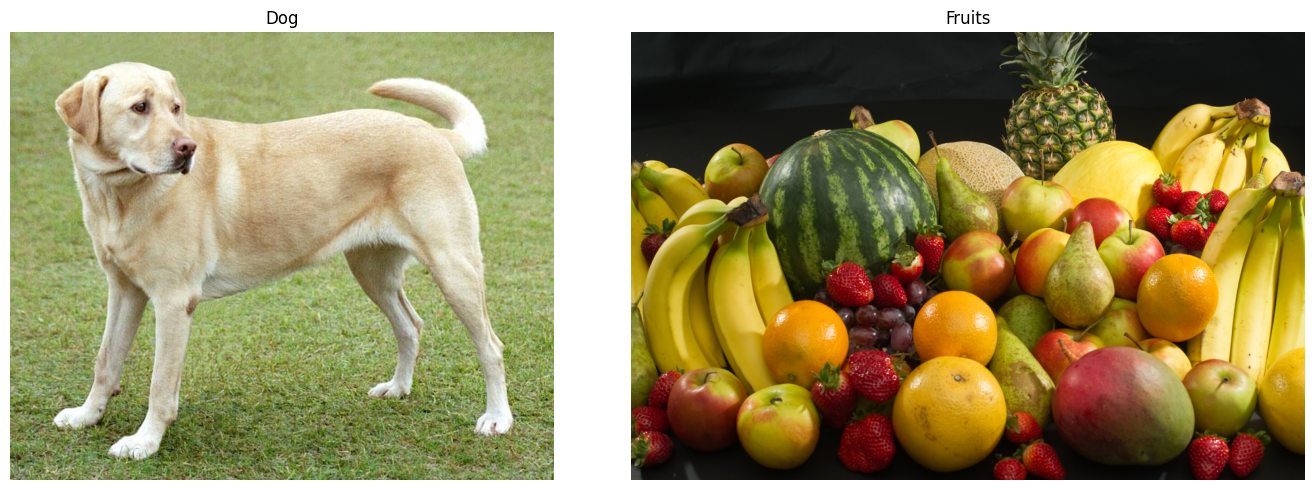

In [ ]:
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; notebook/1.0)"}  # hint: HTTP header key that identifies the client

def load_url(url, max_size=1024):
    img = Image.open(BytesIO(requests.get(url, timeout=15, headers=HEADERS).content)).convert("RGB")  # hint: keyword arg to pass headers
    if max(img.size) > max_size:  # hint: PIL attribute returning (width, height)
        r = max_size / max(img.size)
        img = img.resize(( int(img.width * r), int(img.height * r) ))  # hint: PIL resize method
    return img

dog_img   = load_url("https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/1200px-YellowLabradorLooking_new.jpg")
fruit_img = load_url("https://upload.wikimedia.org/wikipedia/commons/2/2f/Culinary_fruits_front_view.jpg")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(dog_img);   a1.set_title("Dog");    a1.axis("off")  # hint: method to display an image on an axes
a2.imshow(fruit_img); a2.set_title("Fruits"); a2.axis("off")
plt.tight_layout(); plt.show()

## 3. Automatic Mask Generation

* **Segment Everything:** Pass an image to the `mask_gen` pipeline with no prompts. SAM finds and segments every object automatically.

**Hints:**
- The pipeline returns a dict with key `"masks"` — a list of boolean numpy arrays
- Sort masks by total `True` pixel count (descending) so large regions are drawn first, letting small objects appear on top
- Build a 4-channel (RGBA) overlay array with shape `(*mask.shape, 4)` and set `alpha=0.4`

**What each function/expression does:**

| Function / Expression | Description |
|-----------------------|-------------|
| `mask_gen(image, points_per_batch=64)` | Runs automatic segmentation; higher batch = more coverage, slower |
| `result["masks"]` | List of boolean arrays — one per detected segment |
| `np.array(mask).sum()` | Counts pixels inside the mask (used for area sorting) |
| `np.zeros((*shape, 4))` | Creates a transparent RGBA overlay array |
| `ov[mn] = [r, g, b, alpha]` | Sets colour and transparency for mask pixels |
| `np.random.random(3)` | Generates a random RGB colour in [0, 1] |
| `ax.imshow(ov)` | Blends the RGBA overlay onto the existing axes |

**Documentation:**
- [HuggingFace mask-generation pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.ImageSegmentationPipeline)
- [numpy zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html)
- [numpy random](https://numpy.org/doc/stable/reference/random/generated/numpy.random.random.html)

Found 111 segments!


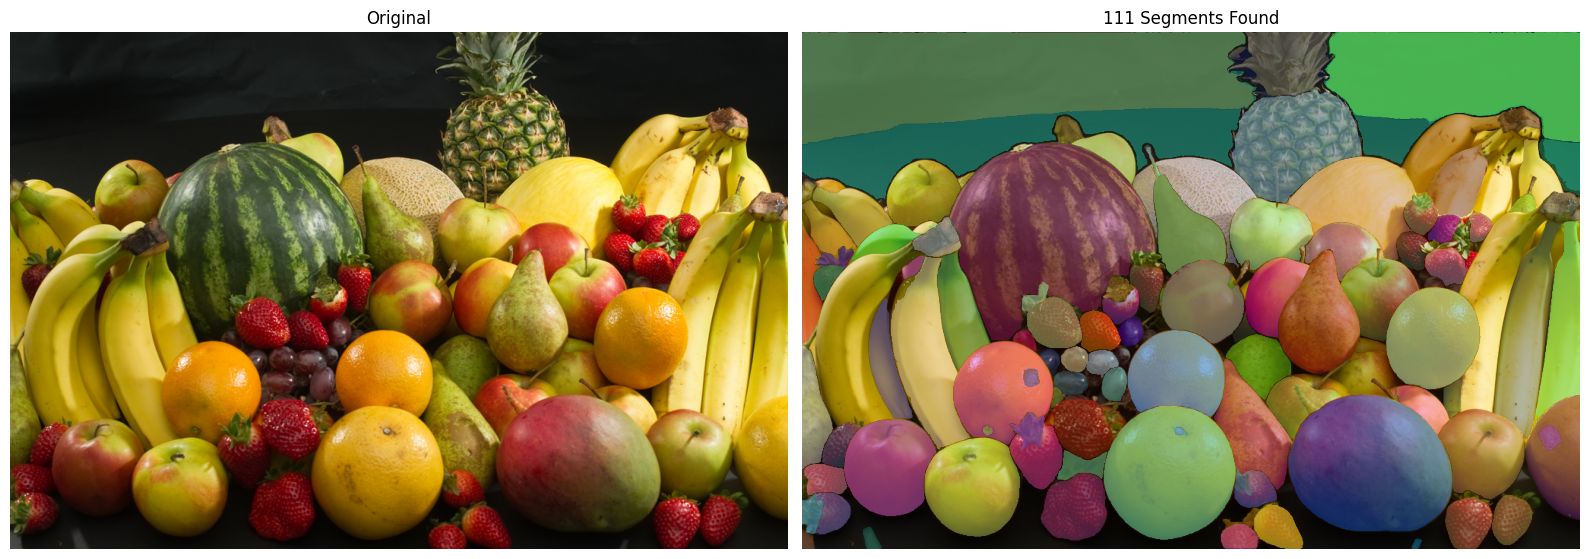

In [ ]:
result = mask_gen(fruit_img, points_per_batch=64)  # hint: pipeline variable defined in cell 2
masks  = result["masks"]  # hint: dict key that holds the list of boolean mask arrays
print(f"Found {len(masks)} segments!")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 6))
a1.imshow(fruit_img); a1.set_title("Original"); a1.axis("off")
a2.imshow(fruit_img)

# Sort masks largest-first so small objects appear on top
for m in sorted(masks, key=lambda m: np.array(m).sum(), reverse=True):  # hint: convert to array; sort direction
    mn = np.array(m)
    ov = np.zeros((*mn.shape, 4))  # hint: shape attribute of mn
    ov[mn] = [*np.random.random(3), 0.4]  # hint: number of channels in RGB
    a2.imshow(ov)

a2.set_title(f"{len(masks)} Segments Found"); a2.axis("off")
plt.tight_layout(); plt.show()

## 4. Point-Prompted Segmentation

* **Click to Isolate:** Provide a single (x, y) point and SAM returns the mask of the object at that location.

**Hints:**
- Wrap the processor output in a manual dict comprehension to cast float tensors to `torch.float32` before moving to MPS/CUDA (MPS does not support float64)
- `sam_model(**inputs)` returns `pred_masks` (shape `[B, 3, H, W]`) and `iou_scores` (shape `[B, 3]`)
- Use `iou_scores.argmax()` to select the best of the 3 candidate masks
- `post_process_masks` resizes masks back to the original image resolution

**What each function/expression does:**

| Function / Expression | Description |
|-----------------------|-------------|
| `sam_processor(image, input_points=[[pt]], input_labels=[[1]])` | Encodes image + foreground point into model inputs |
| `v.is_floating_point()` | Returns True if tensor dtype is float16/32/64 |
| `v.to(torch.float32)` | Casts tensor to 32-bit float (required for MPS) |
| `sam_model(**inputs)` | Runs the SAM forward pass |
| `out.iou_scores.squeeze().argmax()` | Index of the mask with the highest predicted IoU |
| `post_process_masks(pred, orig_sizes, reshaped_sizes)` | Upsamples low-res masks to original image resolution |
| `masks[0][0, best].numpy()` | Extracts the best boolean mask as a numpy array |

**Documentation:**
- [SamModel forward](https://huggingface.co/docs/transformers/model_doc/sam#transformers.SamModel.forward)
- [torch.Tensor.to](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html)
- [numpy scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html)

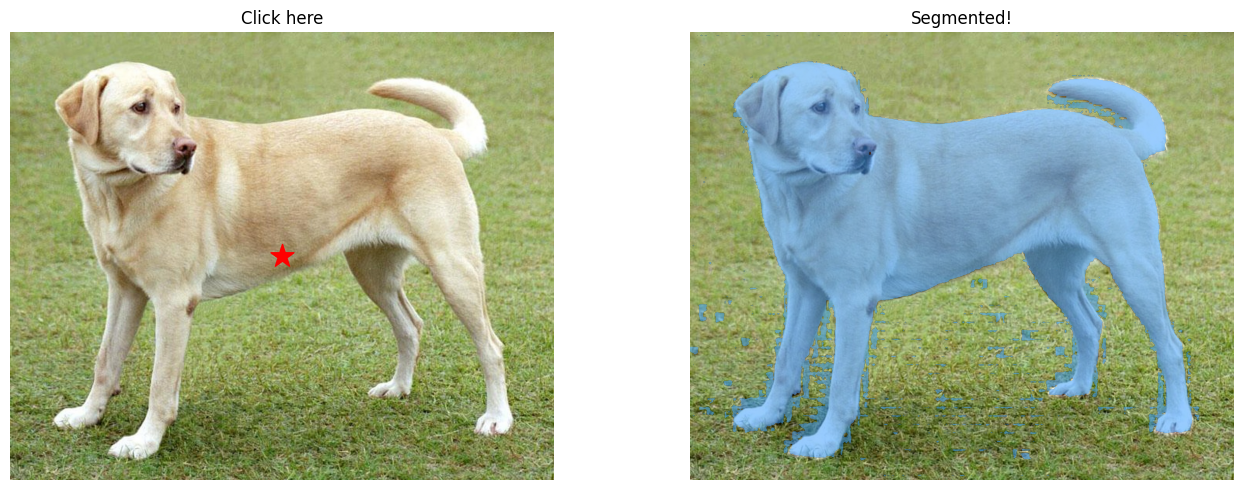

In [ ]:
def segment_at_point(image, point):
    """Segment the object at [x, y]. Returns the best mask."""
    raw = sam_processor(image, input_points=[[point]], input_labels=[[1]], return_tensors="pt")  # hint: the click coord; foreground label value
    # Cast float tensors to float32 (MPS does not support float64)
    inputs = {
        k: v.to(torch.float32).to(device) if isinstance(v, torch.Tensor) and v.is_floating_point()  # hint: float32 dtype; method to check floating point
        else (v.to(device) if isinstance(v, torch.Tensor) else v)
        for k, v in raw.items()  # hint: dict method to iterate key-value pairs
    }
    with torch.no_grad():
        out = sam_model(**inputs)  # hint: the SAM model variable

    pred_masks = sam_processor.image_processor.post_process_masks(  # hint: method that resizes masks back to original resolution
        out.pred_masks.cpu(),
        raw["original_sizes"].cpu(),
        raw["reshaped_input_sizes"].cpu()
    )
    best = out.iou_scores.cpu().squeeze().argmax().item()  # hint: remove size-1 dimensions
    return pred_masks[0][0, best].numpy()  # hint: index of best mask

# Simulate a user click at the centre of the dog image
w, h = dog_img.size  # hint: PIL attribute returning (width, height)
pt = [w // 2, h // 2]
dog_mask = segment_at_point(dog_img, pt)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(dog_img); a1.scatter(*pt, c="red", s=300, marker="*", zorder=5)  # hint: method to plot a point on axes
a1.set_title("Click here"); a1.axis("off")

a2.imshow(dog_img)
ov = np.zeros((*dog_mask.shape, 4)); ov[dog_mask] = [0.2, 0.6, 1.0, 0.5]
a2.imshow(ov); a2.set_title("Segmented!"); a2.axis("off")
plt.tight_layout(); plt.show()

## 5. Application 1 — Background Swap

* **Background Replacement:** Use the dog mask from Section 4 to composite the subject onto a new background.

**Hints:**
- `np.array(pil_image)` converts a PIL Image to an HxWx3 uint8 numpy array
- Build backgrounds as numpy arrays of the same shape as `arr`
- `np.where(condition, a, b)` picks from `a` where condition is True, else from `b`
- Expand the 2D mask to 3 channels with `dog_mask[:, :, None]` for broadcasting

**What each function/expression does:**

| Function / Expression | Description |
|-----------------------|-------------|
| `np.array(dog_img)` | Converts PIL image to HxWx3 numpy array |
| `arr.shape[:2]` | Returns (height, width) of the image array |
| `np.zeros_like(arr)` | Creates a zero array with the same shape and dtype |
| `np.full_like(arr, fill)` | Creates an array filled with a constant colour |
| `np.random.randint(lo, hi, n)` | Generates n random integers for star positions |
| `np.where(mask[:,:,None], arr, bg)` | Composites foreground (mask=True) over background |

**Documentation:**
- [numpy where](https://numpy.org/doc/stable/reference/generated/numpy.where.html)
- [numpy zeros_like](https://numpy.org/doc/stable/reference/generated/numpy.zeros_like.html)
- [numpy full_like](https://numpy.org/doc/stable/reference/generated/numpy.full_like.html)

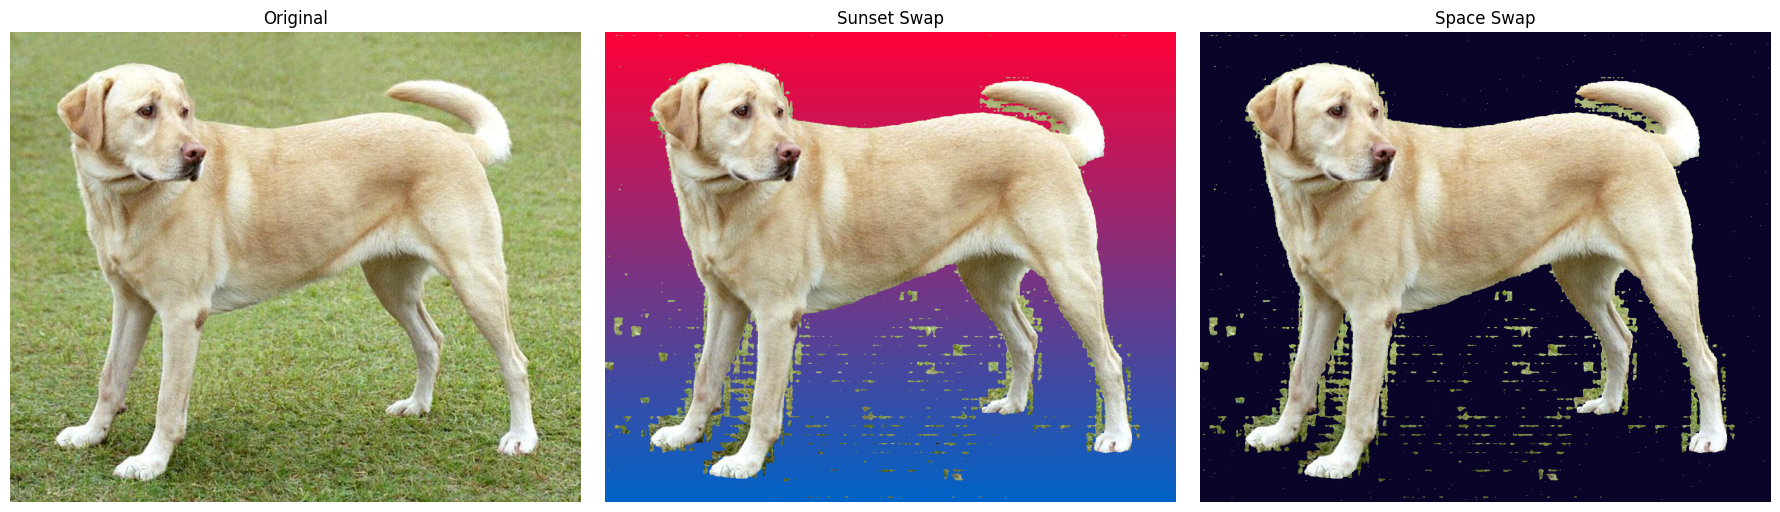

In [ ]:
arr = np.array(dog_img)  # hint: converts PIL Image to numpy array
h_px, w_px = arr.shape[:2]  # hint: shape attribute; keep only height and width

# Sunset gradient: top is warm orange, bottom is purple
sunset = np.zeros_like(arr)  # hint: same shape, all zeros
for i in range(h_px):
    t = i / h_px
    sunset[i] = [int(255*(1-t)), int(100*t), int(200*t + 55*(1-t))]

# Starry sky: dark navy with random bright dots
np.random.seed(42)
sky = np.full_like(arr, [10, 5, 40])  # hint: fill every pixel with this dark-blue colour
sy = np.random.randint(0, h_px, 300)
sx = np.random.randint(0, w_px, 300)
sky[sy, sx] = [255, 255, 220]  # star pixels

m = dog_mask[:, :, None]  # hint: add a trailing dimension for broadcasting across 3 channels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(dog_img);                            axes[0].set_title("Original")
axes[1].imshow(np.where(m, arr, sunset));         axes[1].set_title("Sunset Swap")  # hint: element-wise conditional select
axes[2].imshow(np.where(m, arr, sky));            axes[2].set_title("Space Swap")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

## 6. Application 2 — Object Counter

* **Count Objects:** Use the masks from Section 3 to count and label distinct objects in the fruit image.

**Hints:**
- Filter by relative area: masks smaller than 1% are noise, masks larger than 25% are usually the background
- `fruit_img.size` returns `(width, height)` — multiply them for total pixel count
- `np.where(mask)` returns `(row_indices, col_indices)` of all True pixels — use these for bounding boxes and centroid labels

**What each function/expression does:**

| Function / Expression | Description |
|-----------------------|-------------|
| `fruit_img.size[0] * fruit_img.size[1]` | Total pixel area of the image |
| `np.array(m).sum()` | Count of True pixels = mask area in pixels |
| `np.where(mn)` | Returns (ys, xs) arrays of mask pixel positions |
| `xs.min(), xs.max()` | Left and right edges of the bounding box |
| `plt.Rectangle((x, y), w, h, ...)` | Draws a rectangle patch on matplotlib axes |
| `ax.add_patch(rect)` | Attaches the rectangle to the plot |
| `ax.text(x, y, label, ...)` | Draws a text annotation on the axes |
| `plt.cm.Set3(np.linspace(0,1,n))` | Generates n evenly-spaced colours from the Set3 colourmap |

**Documentation:**
- [matplotlib Rectangle](https://matplotlib.org/stable/api/patches_api.html#matplotlib.patches.Rectangle)
- [matplotlib text](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html)
- [numpy where](https://numpy.org/doc/stable/reference/generated/numpy.where.html)

111 total masks → 35 objects after filtering


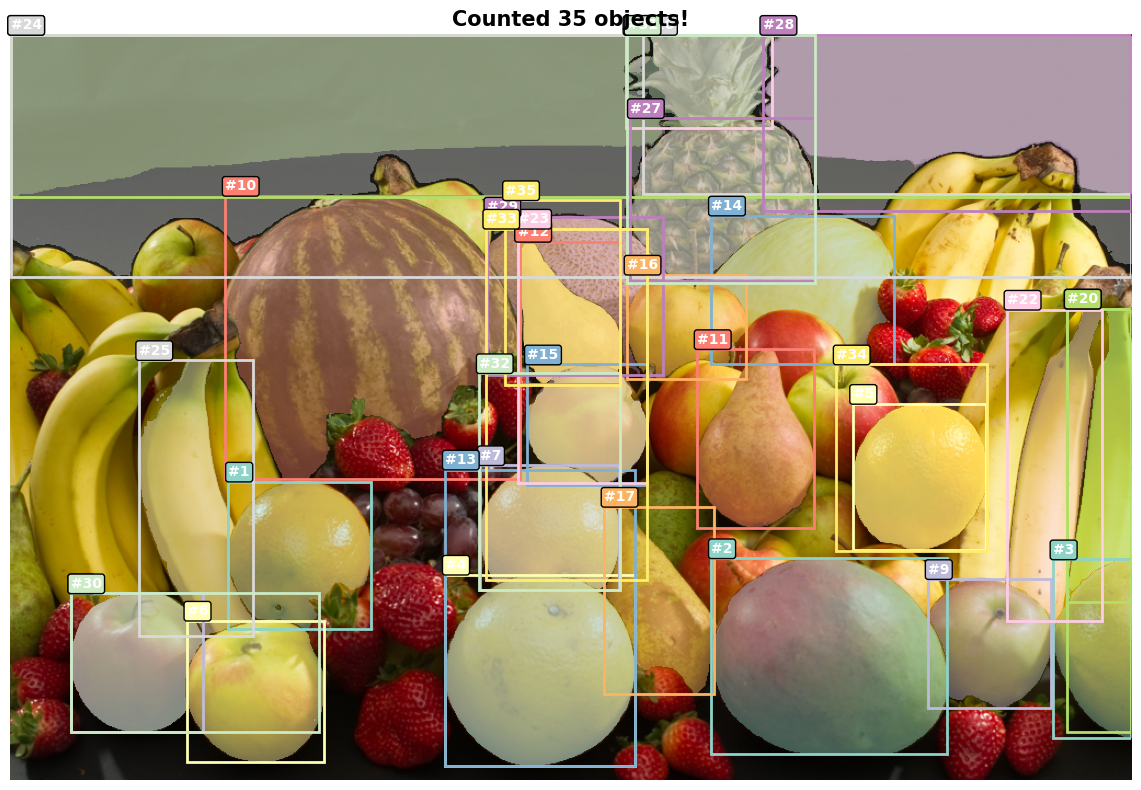

In [ ]:
total = fruit_img.size[0] * fruit_img.size[1]  # hint: PIL attribute for (width, height)

# Keep masks whose area is between 1% and 25% of the total image area
objects = [m for m in masks if 0.01 * total < np.array(m).sum() < 0.25 * total]  # hint: masks list; lower bound; sum method; upper bound
print(f"{len(masks)} total masks → {len(objects)} objects after filtering")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(fruit_img)

colors = plt.cm.Set3(np.linspace(0, 1, len(objects)))  # hint: qualitative colormap name: Set3

for i, m in enumerate(objects):
    mn = np.array(m)
    ov = np.zeros((*mn.shape, 4))
    ov[mn] = [*colors[i][:3], 0.4]
    ax.imshow(ov)

    ys, xs = np.where(mn)  # hint: returns (row_indices, col_indices) of True pixels
    x_min, x_max = xs.min(), xs.max()  # hint: min and max methods
    y_min, y_max = ys.min(), ys.max()

    rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                          linewidth=2, edgecolor=colors[i], facecolor="none")
    ax.add_patch(rect)  # hint: method to attach a patch to the axes
    ax.text(x_min, y_min - 5, f"#{i+1}", fontsize=10, fontweight="bold",
            color="white", bbox=dict(boxstyle="round,pad=0.2", facecolor=colors[i]))

ax.set_title(f"Counted {len(objects)} objects!", fontsize=15, fontweight="bold")
ax.axis("off"); plt.tight_layout(); plt.show()

## Real-World Use Cases

### Where SAM Is Applied

| Domain | Application |
|---|---|
| **Medical Imaging** | Isolate tumors or organs in X-rays and MRIs |
| **Agriculture** | Count crops, detect weeds from drone imagery |
| **Autonomous Driving** | Segment roads, pedestrians, and signs |
| **E-commerce** | One-click background removal for product photos |
| **AR/VR** | Real-time object isolation for AR overlays |
| **Satellite Imagery** | Land-use mapping and flood detection |
| **Video Editing** | Rotoscoping — cut out objects frame by frame |
| **Photo Apps** | Selective color, background blur, object-level style transfer |

### Key Takeaways
- SAM is a **zero-shot** model — no fine-tuning required for new object types
- Three prompt modes: **automatic**, **point**, and **bounding box**
- Runs on CPU; significantly faster on GPU or Apple MPS
- Pair with a downstream classifier for domain-specific pipelines